In [1]:
import pandas as pd

# Load your dataset
df = pd.read_csv("preprocessed_kids_screentime.csv")

df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Urban_or_Rural,Age_Band,High_Screen_Time
0,14,Male,3.99,Smartphone,True,0.42,Urban,11-15,False
1,11,Female,4.61,Laptop,True,0.30,Urban,11-15,True
2,18,Female,3.73,Tv,True,0.32,Urban,16-18,False
3,15,Female,1.21,Laptop,False,0.39,Urban,11-15,False
4,12,Female,5.89,Smartphone,True,0.49,Urban,11-15,True


In [2]:
df["Cohort"] = (
    df["Age_Band"].astype(str) + " | " +
    df["High_Screen_Time"].astype(str) + " | " +
    df["Urban_or_Rural"].astype(str)
)

df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Urban_or_Rural,Age_Band,High_Screen_Time,Cohort
0,14,Male,3.99,Smartphone,True,0.42,Urban,11-15,False,11-15 | False | Urban
1,11,Female,4.61,Laptop,True,0.30,Urban,11-15,True,11-15 | True | Urban
2,18,Female,3.73,Tv,True,0.32,Urban,16-18,False,16-18 | False | Urban
3,15,Female,1.21,Laptop,False,0.39,Urban,11-15,False,11-15 | False | Urban
4,12,Female,5.89,Smartphone,True,0.49,Urban,11-15,True,11-15 | True | Urban


In [3]:
segment_summary = df.groupby("Cohort").agg(
    Avg_Screen_Time=("Avg_Daily_Screen_Time_hr", "mean"),
    Max_Screen_Time=("Avg_Daily_Screen_Time_hr", "max"),
    Min_Screen_Time=("Avg_Daily_Screen_Time_hr", "min"),
    Count=("Cohort", "count"),
    Limit_Exceeded_Rate=("Exceeded_Recommended_Limit", "mean"),
    Educational_Ratio_Mean=("Educational_to_Recreational_Ratio", "mean")
).reset_index()

segment_summary


,Cohort,Avg_Screen_Time,Max_Screen_Time,Min_Screen_Time,Count,Limit_Exceeded_Rate,Educational_Ratio_Mean
0,11-15 | False | Rural,3.197986,4.00,0.50,432,0.687500,0.397176
1,11-15 | False | Urban,3.214274,4.00,0.16,1067,0.705717,0.400825
2,11-15 | True | Rural,5.154838,8.74,4.01,864,1.000000,0.402292
3,11-15 | True | Urban,5.175059,8.55,4.01,2040,1.000000,0.399363
4,16-18 | False | Rural,3.199283,4.00,0.65,237,0.679325,0.399241
5,16-18 | False | Urban,3.227580,4.00,0.00,628,0.708599,0.399459
6,16-18 | True | Rural,5.163081,8.67,4.01,529,1.000000,0.399698
7,16-18 | True | Urban,5.189919,8.27,4.01,1241,1.000000,0.396680
8,6-10 | False | Rural,1.830995,3.99,0.00,402,0.482587,0.495622
9,6-10 | False | Urban,1.906145,4.00,0.00,996,0.503012,0.500060


In [4]:
device_patterns = df.groupby("Primary_Device").agg(
    Avg_Screen_Time=("Avg_Daily_Screen_Time_hr", "mean"),
    High_Screen_Time_Rate=("High_Screen_Time", "mean"),
    Count=("Primary_Device", "count")
).reset_index()

device_patterns


,Primary_Device,Avg_Screen_Time,High_Screen_Time_Rate,Count
0,Laptop,4.459086,0.650384,1433
1,Smartphone,4.388925,0.626532,4568
2,Tablet,4.226005,0.572712,1224
3,Tv,4.287752,0.585042,2487


In [5]:
gender_comparison = df.groupby("Gender").agg(
    Avg_Screen_Time=("Avg_Daily_Screen_Time_hr", "mean"),
    Limit_Exceeded_Rate=("Exceeded_Recommended_Limit", "mean"),
    Recreational_Preference=("Educational_to_Recreational_Ratio", "mean")
).reset_index()

gender_comparison


,Gender,Avg_Screen_Time,Limit_Exceeded_Rate,Recreational_Preference
0,Female,4.327021,0.843816,0.426694
1,Male,4.377754,0.865237,0.427740


In [6]:
age_band_patterns = df.groupby("Age_Band").agg(
    Avg_Screen_Time=("Avg_Daily_Screen_Time_hr", "mean"),
    High_Screen_Time_Rate=("High_Screen_Time", "mean"),
    Limit_Exceeded_Rate=("Exceeded_Recommended_Limit", "mean")
).reset_index()

age_band_patterns


,Age_Band,Avg_Screen_Time,High_Screen_Time_Rate,Limit_Exceeded_Rate
0,11-15,4.501944,0.659550,0.898024
1,16-18,4.537803,0.671727,0.901708
2,6-10,3.925049,0.477188,0.737098


In [7]:
habit_matrix = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Urban_or_Rural",
    aggfunc="mean"
)

habit_matrix


Urban_or_Rural,Rural,Urban
Age_Band,,
11-15,4.502554,4.501690
16-18,4.555483,4.530556
6-10,3.990426,3.897189


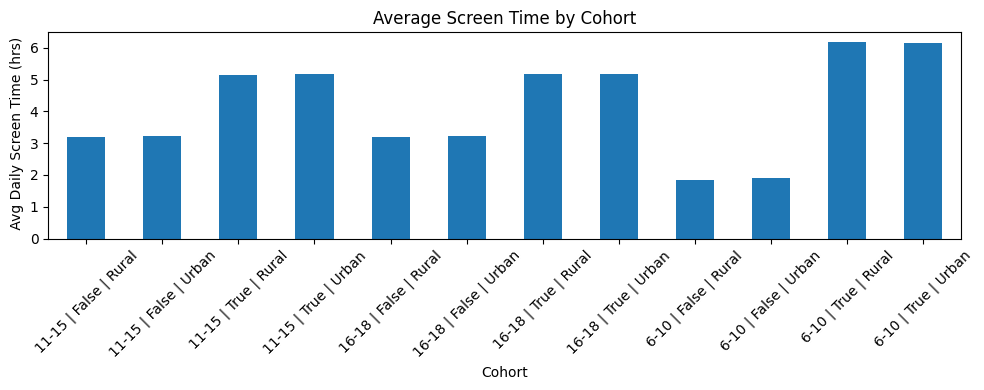

In [8]:
import matplotlib.pyplot as plt

cohort_data = df.groupby("Cohort")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(10,4))
cohort_data.plot(kind='bar')
plt.title("Average Screen Time by Cohort")
plt.xlabel("Cohort")
plt.ylabel(" Avg Daily Screen Time (hrs)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


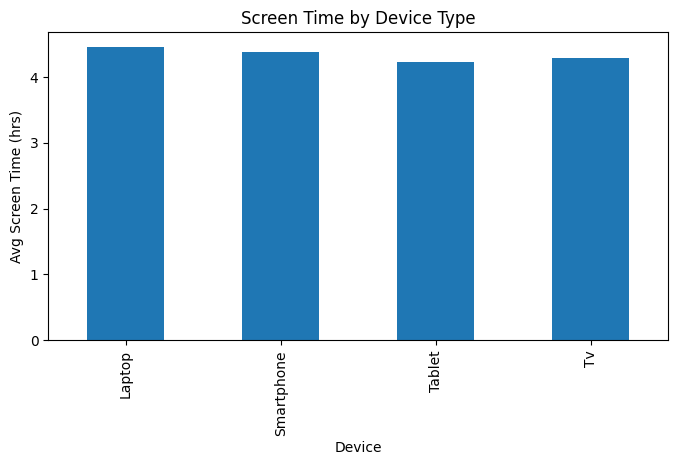

In [9]:
device_data = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(8,4))
device_data.plot(kind='bar')
plt.title("Screen Time by Device Type")
plt.xlabel("Device")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()


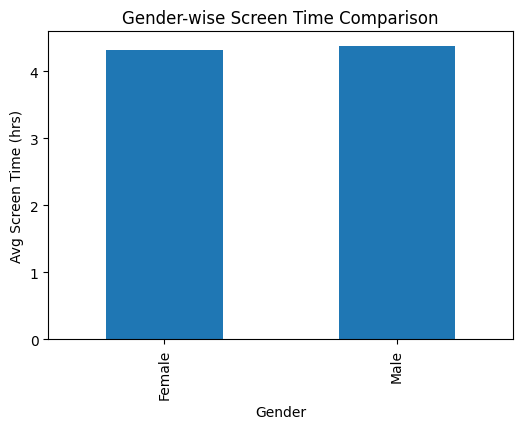

In [10]:
gender_data = df.groupby("Gender")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(6,4))
gender_data.plot(kind='bar')
plt.title("Gender-wise Screen Time Comparison")
plt.xlabel("Gender")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()


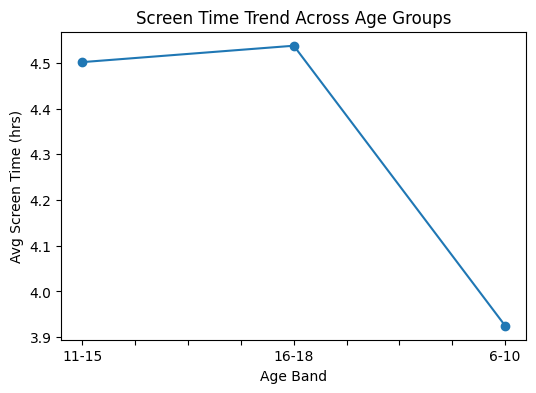

In [11]:
age_trend = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean()

plt.figure(figsize=(6,4))
age_trend.plot(kind='line', marker='o')
plt.title("Screen Time Trend Across Age Groups")
plt.xlabel("Age Band")
plt.ylabel("Avg Screen Time (hrs)")
plt.show()


In [12]:
heatmap_matrix = df.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Urban_or_Rural",
    aggfunc="mean"
)

print("\nHeatmap Data:\n")
print(heatmap_matrix)



Heatmap Data:

Urban_or_Rural     Rural     Urban
Age_Band                          
11-15           4.502554  4.501690
16-18           4.555483  4.530556
6-10            3.990426  3.897189


In [2]:
import pandas as pd

# Load your dataset
df1 = pd.read_csv("preprocessed_kids_screentime.csv")

df1.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Urban_or_Rural,Age_Band,High_Screen_Time
0,14,Male,3.99,Smartphone,True,0.42,Urban,11-15,False
1,11,Female,4.61,Laptop,True,0.30,Urban,11-15,True
2,18,Female,3.73,Tv,True,0.32,Urban,16-18,False
3,15,Female,1.21,Laptop,False,0.39,Urban,11-15,False
4,12,Female,5.89,Smartphone,True,0.49,Urban,11-15,True


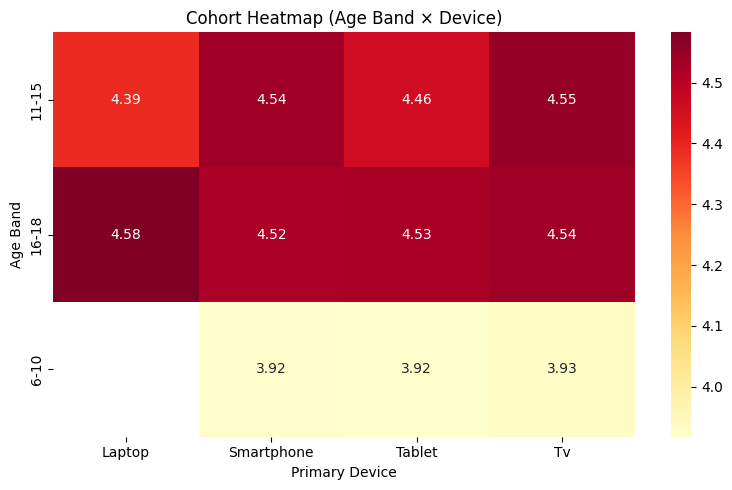

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table for heatmap
heatmap_data = df1.pivot_table(
    values="Avg_Daily_Screen_Time_hr",
    index="Age_Band",
    columns="Primary_Device",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Cohort Heatmap (Age Band × Device)")
plt.xlabel("Primary Device")
plt.ylabel("Age Band")
plt.tight_layout()
plt.show()


In [6]:
df1["Cohort"] = (
    df1["Age_Band"].astype(str) + " | " +
    df1["Primary_Device"].astype(str) + " | " +
    df1["Urban_or_Rural"].astype(str) + " | " +
    df1["High_Screen_Time"].astype(str)
)
